<a href="https://colab.research.google.com/github/jeanbaptistehabimanaMIT2026/MIT-projects-2026/blob/main/(PROJECT_OF_DATA_MINING_FOR_BUSINESS_INTELLIGENCE_EXAM)GROUP6_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom Customer Churn Analysis
**Group 6- Data Mining or Business Intelligence**

Dataset: `telecom_customer_data.csv` — 403 MTN Rwanda customer records, 18 columns.

**Business question:** *Who is most likely to leave us, and why?*

This notebook works through the three required tasks in order:
1. **Data Cleaning** — Find and fix data quality problems, save `telecom_clean.csv`.
2. **Exploratory Data Analysis** — Answer the three business questions plus one extra discovery.
3. **Machine Learning** — Build and evaluate a classifier that predicts churn.

Every code cell is preceded or followed by a short markdown note explaining **why** a
particular decision was made (not just what the code does), so the reasoning is visible
next to the evidence.

# Section A — Data Understanding & Cleaning (Task 1)

### A0. Setup
We import `pandas`/`numpy` for data handling, `matplotlib` for charts, and the
`sklearn` pieces used later for the classifier and its evaluation metrics. Everything is
imported once, up front, so later sections don't need to repeat import boilerplate.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
import warnings
warnings.filterwarnings('ignore')

# A consistent style for every chart in this notebook
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('All libraries loaded!')

All libraries loaded!


### A1. Load the data and check its shape
The brief tells us to expect 403 rows and 18 columns. We check that immediately after
loading, if the shape doesn't match, something went wrong with the file path or the
delimiter before we've done any real work.

In [3]:
df = pd.read_csv('telecom_customer_data.csv')

print('Dataset loaded!')
print('Rows    :', df.shape[0])
print('Columns :', df.shape[1])
df.head()

Dataset loaded!
Rows    : 403
Columns : 18


,CustomerID,Region,AgeGroup,Gender,SubscriptionPlan,TenureMonths,MonthlyChargeFRW,DataUsedGB,CallMinutes,SMSCount,ComplaintCount,SupportCalls,NetworkQualityScore,PaymentDelayDays,Channel,SatisfactionScore,Churned,TotalRevenue6M
0,MTN00001,Kigali,55+,Male,Basic,37,3655,9.6,680,2,7,8,4.9,8.0,Mobile App,5.3,0,15359
1,MTN00002,Kigali,18-24,Male,Premium,62,17932,37.2,370,124,4,3,3.5,3.0,USSD,NaN,1,90541
2,MTN00003,Kigali,35-44,Male,Basic,3,3594,12.9,768,139,5,9,2.0,10.0,USSD,6.4,1,18199
3,MTN00004,Eastern Province,45-54,Male,Basic,6,3311,30.5,556,112,5,0,4.2,4.0,USSD,6.5,1,18494
4,MTN00005,Northern Province,45-54,Female,Business,15,34769,42.9,351,102,5,0,1.7,13.0,Web,5.5,0,148883


**Output explained:** the shape (403 rows, 18 columns) matches the brief exactly, so
the file loaded correctly with no rows dropped or columns merged by a wrong delimiter.
`head()` gives a first visual read of what "normal" looks like before we start hunting
for what's abnormal.

### A2. Column data types
We check `dtypes` because pandas' inferred type does not always match what a column
*should* be. If a numeric column had been read in as text (e.g. because of a stray
symbol in one cell), it would show up here as `object` instead of `int64`/`float64`,
and that would break every calculation downstream.

In [4]:
print('Column data types:')
print(df.dtypes)
print()
print('Summary count by type:')
print(df.dtypes.value_counts())

Column data types:
CustomerID              object
Region                  object
AgeGroup                object
Gender                  object
SubscriptionPlan        object
TenureMonths             int64
MonthlyChargeFRW         int64
DataUsedGB             float64
CallMinutes              int64
SMSCount                 int64
ComplaintCount           int64
SupportCalls             int64
NetworkQualityScore    float64
PaymentDelayDays       float64
Channel                 object
SatisfactionScore      float64
Churned                  int64
TotalRevenue6M           int64
dtype: object

Summary count by type:
int64      8
object     6
float64    4
Name: count, dtype: int64


**Output explained:** every numeric column (Tenure, charges, usage, counts, scores,
revenue) is already `int64` or `float64`, and the five text columns
(Region, AgeGroup, Gender, SubscriptionPlan, Channel) plus `CustomerID` are text/object.
Nothing needs a type conversion — the quality problems in this dataset are about
*values*, not column types.

### A3. Missing values
This is the first concrete evidence of the data-quality problems the brief warns about.
Counting `isnull()` per column tells us exactly which columns need attention in the
cleaning step, and roughly how much of the column is affected (a column that is 60%
missing needs a different strategy than one that is 2% missing).

In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Total missing cells:', df.isnull().sum().sum())
print('Rows with at least one missing value:', df.isnull().any(axis=1).sum())

Missing values per column:
CustomerID              0
Region                  0
AgeGroup                0
Gender                  0
SubscriptionPlan        0
TenureMonths            0
MonthlyChargeFRW        0
DataUsedGB              8
CallMinutes             0
SMSCount                0
ComplaintCount          0
SupportCalls            0
NetworkQualityScore    12
PaymentDelayDays        6
Channel                 0
SatisfactionScore       9
Churned                 0
TotalRevenue6M          0
dtype: int64

Total missing cells: 35
Rows with at least one missing value: 35


**Output explained:** four numeric columns have missing values — `DataUsedGB` (8),
`NetworkQualityScore` (12), `PaymentDelayDays` (6) and `SatisfactionScore` (9), 35 cells
in total, spread across 35 different rows (no row is missing more than one value). This
is a small enough fraction of 403 rows (under 3% per column) that **imputing** these
values is safer than dropping rows — dropping would throw away otherwise-good data for
the other 17 columns in each of those rows.

### A4. `describe()` — a first sanity check
We run `describe()` early: the min/max/mean for each numeric column gives a first hint
of impossible values before we run a formal outlier test. A satisfaction score with a
max above 10, or a monthly charge that dwarfs every other row, jumps out here already.

In [6]:
df.describe()

,TenureMonths,MonthlyChargeFRW,DataUsedGB,CallMinutes,SMSCount,ComplaintCount,SupportCalls,NetworkQualityScore,PaymentDelayDays,SatisfactionScore,Churned,TotalRevenue6M
count,403.000000,403.000000,395.000000,403.000000,403.000000,403.000000,403.000000,391.000000,397.000000,394.000000,403.000000,403.000000
mean,36.263027,13686.779156,27.761772,419.342432,101.503722,3.588089,4.488834,3.069821,14.108312,6.415228,0.327543,58378.320099
std,21.289179,42942.942312,51.145981,528.642274,56.851923,2.290812,2.911078,1.148895,8.546123,1.969545,0.469901,51086.878253
min,1.000000,3206.000000,0.300000,16.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.900000,0.000000,13181.000000
25%,17.000000,3585.000000,13.050000,198.000000,50.000000,2.000000,2.000000,2.100000,7.000000,5.100000,0.000000,18425.500000
50%,36.000000,8444.000000,25.500000,398.000000,106.000000,4.000000,4.000000,3.100000,14.000000,6.400000,0.000000,41757.000000
75%,56.000000,17891.500000,38.850000,578.000000,148.000000,5.000000,7.000000,4.000000,21.000000,7.675000,1.000000,83330.000000
max,71.000000,850000.000000,999.000000,9999.000000,199.000000,7.000000,9.000000,5.000000,29.000000,25.000000,1.000000,207112.000000


**Output explained:** three numbers immediately look wrong given the column
definitions in the brief:
- `MonthlyChargeFRW` max = 850,000 — far above the 75th percentile of ~17,900, and no
  subscription tier plausibly costs that much per month.
- `DataUsedGB` max = 999.0 and `CallMinutes` max = 9999 — both look like placeholder /
  sentinel values rather than real usage figures (real usage tops out far lower).
- `SatisfactionScore` max = 25.0 — the brief defines this scale as 1–10, so 25 is
  outside the valid range by construction, not just statistically unusual.

These four get investigated properly in the outlier check below rather than assumed —
`describe()` is only a first hint.

### A5. Blank strings
`df.isnull()` only catches actual `NaN` values. A blank string `''` is a *different*
kind of missing value — pandas does not treat it as null, so it would silently pass the
missing-value check above while still being unusable text data. Checking for it
separately closes that gap.

In [7]:
print('Blank strings per text column:')
for col in df.select_dtypes(include='object'):
    print(col, (df[col] == '').sum())

Blank strings per text column:
CustomerID 0
Region 0
AgeGroup 0
Gender 0
SubscriptionPlan 0
Channel 0


**Output explained:** no column contains an empty string — every text field that
looks "missing" would have shown up as `NaN` already in A3, not as `''`. This rules out
one category of hidden missing data, so we can move on to outliers and inconsistent
text with confidence that blanks aren't an issue.

### A6. Outlier detection — IQR method
**Why IQR:** any value further than 1.5 × IQR from the 25th/75th percentile is flagged.
This is a standard, distribution-agnostic rule of thumb that works without assuming the
data is normally distributed (which skewed columns like `TotalRevenue6M` are not). It
gives an *evidence-based* shortlist of candidate outliers, rather than us guessing which
columns to inspect.

In [8]:
num_cols = ['TenureMonths', 'MonthlyChargeFRW', 'DataUsedGB', 'CallMinutes',
            'SMSCount', 'ComplaintCount', 'SupportCalls', 'NetworkQualityScore',
            'PaymentDelayDays', 'SatisfactionScore', 'TotalRevenue6M']

print('Outliers per column (IQR method, 1.5x rule):')
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    if len(outliers) > 0:
        print(f'{col}: IQR bounds [{lower:.1f}, {upper:.1f}] -> {len(outliers)} outlier(s)')
        print(outliers[['CustomerID', 'SubscriptionPlan', col]].to_string(index=False))
        print()

Outliers per column (IQR method, 1.5x rule):
MonthlyChargeFRW: IQR bounds [-17874.8, 39351.2] -> 1 outlier(s)
CustomerID SubscriptionPlan  MonthlyChargeFRW
  MTN00034            Basic            850000

DataUsedGB: IQR bounds [-25.7, 77.6] -> 1 outlier(s)
CustomerID SubscriptionPlan  DataUsedGB
  MTN00008         Standard       999.0

CallMinutes: IQR bounds [-372.0, 1148.0] -> 1 outlier(s)
CustomerID SubscriptionPlan  CallMinutes
  MTN00090         Standard         9999

SatisfactionScore: IQR bounds [1.2, 11.5] -> 1 outlier(s)
CustomerID SubscriptionPlan  SatisfactionScore
  MTN00146          Premium               25.0

TotalRevenue6M: IQR bounds [-78931.2, 180686.8] -> 19 outlier(s)
CustomerID SubscriptionPlan  TotalRevenue6M
  MTN00064         Business          186482
  MTN00077         Business          206697
  MTN00078         Business          202153
  MTN00133         Business          203074
  MTN00141         Business          200363
  MTN00142         Business          1897

**Output explained — this is where we decide what's a genuine error vs. a genuine
extreme customer:**
- `MonthlyChargeFRW`: **MTN00034** at 850,000 — this customer is on the **Basic** plan,
  where every other customer pays roughly 3,200–3,800 FRW/month. 850,000 is not a
  premium customer, it's a data-entry error (almost certainly a stray extra digits).
  → treat as invalid.
- `DataUsedGB`: **MTN00008** at 999.0 GB — every other customer in the dataset uses
  under 50 GB/month; 999 is a classic sentinel/placeholder value, not real usage.
  → treat as invalid.
- `CallMinutes`: **MTN00090** at 9999 minutes — same pattern, a round sentinel value far
  beyond the realistic range (everyone else is under ~1,150 minutes). → treat as invalid.
- `SatisfactionScore`: **MTN00146** at 25.0 — the brief defines this scale as 1–10, so
  25 is impossible by definition (likely a missing decimal point, e.g. "2.5" entered as
  "25"). → treat as invalid.
- `TotalRevenue6M`: 19 rows flagged, but checking them shows **every one is a Business
  plan customer** paying ~35,000 FRW/month — 35,000 × 6 ≈ 200,000+, which lines up
  exactly with their revenue. These are genuine high-value customers, not errors.
  → **kept as-is**, no fix needed. This is the reason we always inspect flagged rows by
  hand instead of auto-removing every statistical outlier: IQR finds *candidates*, it
  doesn't tell us which ones are mistakes.

So four specific cell values (not four whole rows) are genuine data-entry errors and
will be corrected in Task A2; `TotalRevenue6M`'s high earners are real and stay.

### A7. Categorical / text inconsistencies
`value_counts(dropna=False)` shows every distinct spelling pandas sees for a category
column, including the count for each. If the same real-world category is being split
into two "different" categories by inconsistent capitalisation (e.g. `Kigali` vs
`kigali`), it will show up here as two separate rows.

In [9]:
cat_cols = ['Region', 'AgeGroup', 'Gender', 'SubscriptionPlan', 'Channel']
for col in cat_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False))
    print()

--- Region ---
Region
Kigali               164
Eastern Province      79
Western Province      63
Northern Province     61
Southern Province     35
kigali                 1
Name: count, dtype: int64

--- AgeGroup ---
AgeGroup
25-34    126
35-44    120
18-24     80
45-54     47
55+       30
Name: count, dtype: int64

--- Gender ---
Gender
Female    203
Male      199
male        1
Name: count, dtype: int64

--- SubscriptionPlan ---
SubscriptionPlan
Basic       151
Standard    124
Premium      80
Business     47
BASIC         1
Name: count, dtype: int64

--- Channel ---
Channel
Mobile App    142
USSD          100
Agent          81
Web            50
Walk-in        29
mobile app      1
Name: count, dtype: int64



**Output explained:** four columns have a casing inconsistency that splits one real
category into two rows in the counts above:
- `Region`: `Kigali` (most rows) and `kigali` (lower-case, a handful of rows) are the
  same province.
- `Gender`: `Male` and `male` are the same category.
- `SubscriptionPlan`: `Basic` and `BASIC` are the same tier.
- `Channel`: `Mobile App` and `mobile app` are the same channel.

`AgeGroup` has no inconsistency — its five brackets are spelled consistently. These
four columns need text standardisation (not new values, not deletions) in Task A2, or
group-by charts in Task 2 would undercount the "real" category and show a
phantom near-duplicate one.

### A8. Duplicate rows
We check duplicates two ways: **including** `CustomerID` (a true, exact duplicate
record — same customer, same everything) and **excluding** it (would catch two
different customer IDs that otherwise have identical data, which would suggest a
copy-paste error in the ID column itself). Both checks together confirm what kind of
duplication we're dealing with before we decide how to remove it.

In [10]:
full_dupes = df[df.duplicated(keep=False)]
print('Fully duplicated rows (exact match on all columns, including CustomerID):', len(full_dupes))
print(full_dupes[['CustomerID', 'Region', 'Gender', 'SubscriptionPlan']])

no_id = df.drop(columns=['CustomerID'])
dupes_no_id = df[no_id.duplicated(keep=False)]
print()
print('Duplicated rows ignoring CustomerID:', len(dupes_no_id))

Fully duplicated rows (exact match on all columns, including CustomerID): 6
    CustomerID             Region  Gender SubscriptionPlan
10    MTN00011             Kigali  Female         Standard
50    MTN00051             Kigali  Female         Standard
120   MTN00121  Northern Province  Female         Business
400   MTN00011             Kigali  Female         Standard
401   MTN00051             Kigali  Female         Standard
402   MTN00121  Northern Province  Female         Business

Duplicated rows ignoring CustomerID: 6


**Output explained:** 6 rows are involved in 3 duplicate pairs (customers
MTN00011, MTN00051, MTN00121), and the "ignoring CustomerID" count is identical (6) —
meaning these are **true, exact duplicates**: the same CustomerID appears twice with
identical values in every other column too, most likely from the same record being
appended to the file twice. There's no ambiguity about which copy to keep, since the
two copies of each customer are identical — we simply drop the extra copy in Task A2.

## Task A2 — Data Cleaning
Now that A1 has produced clear, row-level evidence for every problem, we fix them in a
deliberate order: **(1) standardise text** so groupings are correct, **(2) correct the
four impossible cell values** identified in A6 by turning them into `NaN` (rather than
guessing a replacement number), **(3) impute all missing values** (original + the ones
we just created) in one consistent pass, then **(4) drop the exact duplicate rows**.
Doing text and outlier fixes *before* imputation matters: imputing first and fixing
outliers after would let a genuine sentinel value like 999 GB pull the median/mean used
for imputation off course.

### A2.1 Standardise inconsistent text
**Problem (from A7):** `Region`, `Gender`, `SubscriptionPlan` and `Channel` each have one
value duplicated under different capitalisation. **Fix:** map the odd-cased spelling to
the standard one already used by the majority of rows, rather than blindly
`.title()`-casing everything (which would break multi-word values like `Mobile App` or
`Eastern Province` inconsistently).

In [11]:
print('BEFORE:')
print('Region:', sorted(df['Region'].unique()))
print('Gender:', sorted(df['Gender'].unique()))
print('SubscriptionPlan:', sorted(df['SubscriptionPlan'].unique()))
print('Channel:', sorted(df['Channel'].unique()))

df['Region'] = df['Region'].replace({'kigali': 'Kigali'})
df['Gender'] = df['Gender'].replace({'male': 'Male'})
df['SubscriptionPlan'] = df['SubscriptionPlan'].replace({'BASIC': 'Basic'})
df['Channel'] = df['Channel'].replace({'mobile app': 'Mobile App'})

print()
print('AFTER:')
print('Region:', sorted(df['Region'].unique()))
print('Gender:', sorted(df['Gender'].unique()))
print('SubscriptionPlan:', sorted(df['SubscriptionPlan'].unique()))
print('Channel:', sorted(df['Channel'].unique()))

BEFORE:
Region: ['Eastern Province', 'Kigali', 'Northern Province', 'Southern Province', 'Western Province', 'kigali']
Gender: ['Female', 'Male', 'male']
SubscriptionPlan: ['BASIC', 'Basic', 'Business', 'Premium', 'Standard']
Channel: ['Agent', 'Mobile App', 'USSD', 'Walk-in', 'Web', 'mobile app']

AFTER:
Region: ['Eastern Province', 'Kigali', 'Northern Province', 'Southern Province', 'Western Province']
Gender: ['Female', 'Male']
SubscriptionPlan: ['Basic', 'Business', 'Premium', 'Standard']
Channel: ['Agent', 'Mobile App', 'USSD', 'Walk-in', 'Web']


**Output explained:** each of the four columns now has exactly the number of
categories the brief implies (5 regions, 2 genders, 4 plans, 5 channels) instead of one
extra "duplicate" category. Every customer is now counted under one, correctly-spelled
group — this matters directly for Task 2's churn-rate-by-plan and churn-rate-by-region
charts, which would otherwise silently understate the Basic/Kigali/Mobile App totals.

### A2.2 Correct impossible values (outliers) → NaN
**Problem (from A6):** MTN00034's `MonthlyChargeFRW` (850,000), MTN00008's `DataUsedGB`
(999), MTN00090's `CallMinutes` (9999) and MTN00146's `SatisfactionScore` (25) are all
either physically implausible for their context or outside the scale defined in the
brief. **Fix:** we replace these four cells with `NaN` rather than deleting the whole
row (each customer has 17 other perfectly good data points) or guessing a "corrected"
number (we have no reliable way to know what the true value was) — treating them as
missing lets the imputation step below fill them in consistently with every other
missing value, using a defensible statistical rule instead of a manual guess.

In [12]:
print('BEFORE:')
print(df.loc[df.CustomerID == 'MTN00034', 'MonthlyChargeFRW'].values)
print(df.loc[df.CustomerID == 'MTN00008', 'DataUsedGB'].values)
print(df.loc[df.CustomerID == 'MTN00090', 'CallMinutes'].values)
print(df.loc[df.CustomerID == 'MTN00146', 'SatisfactionScore'].values)

df.loc[df['MonthlyChargeFRW'] == 850000, 'MonthlyChargeFRW'] = np.nan
df.loc[df['DataUsedGB'] == 999, 'DataUsedGB'] = np.nan
df.loc[df['CallMinutes'] == 9999, 'CallMinutes'] = np.nan
df.loc[df['SatisfactionScore'] == 25, 'SatisfactionScore'] = np.nan

print()
print('AFTER (now NaN, to be imputed in A2.3):')
print(df.loc[df.CustomerID == 'MTN00034', 'MonthlyChargeFRW'].values)
print(df.loc[df.CustomerID == 'MTN00008', 'DataUsedGB'].values)
print(df.loc[df.CustomerID == 'MTN00090', 'CallMinutes'].values)
print(df.loc[df.CustomerID == 'MTN00146', 'SatisfactionScore'].values)

print()
print('Total missing values now (original 35 + 4 new):', df.isnull().sum().sum())

BEFORE:
[850000]
[999.]
[9999]
[25.]

AFTER (now NaN, to be imputed in A2.3):
[nan]
[nan]
[nan]
[nan]

Total missing values now (original 35 + 4 new): 39


**Output explained:** the four impossible cells are now `NaN` instead of
nonsensical numbers, and the total missing-cell count has risen from 35 to 39 as
expected (35 original + 4 just converted). Nothing has been deleted — all 403 rows and
403 CustomerIDs are still present at this point; we've only marked four specific values
as "unknown" instead of "wrong-but-present", which is what lets us fix them
statistically in the next step.

### A2.3 Handle missing values — median imputation
**Why median, not mean:** the mean is pulled around by skew and by any remaining
extreme values (e.g. `TotalRevenue6M`'s legitimate Business-plan earners), so it would
not represent a "typical" customer. The median is robust to that skew and gives a
realistic fill value. **Why impute at all, not drop rows:** the missing cells are
scattered thinly across ~39 of 403 rows (under 10%) and never overlap on the same row
more than needed — dropping them would throw away good data in the other columns of
those rows for no real gain in data quality.

In [13]:
num_cols_with_na = ['DataUsedGB', 'NetworkQualityScore', 'PaymentDelayDays',
                     'SatisfactionScore', 'MonthlyChargeFRW', 'CallMinutes']

print('Skew of each affected column (justifies median over mean):')
print(df[num_cols_with_na].skew().round(2))
print()

for col in num_cols_with_na:
    median_val = df[col].median()
    n_missing = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'{col}: filled {n_missing} missing value(s) with median = {median_val}')

print()
print('Total missing values remaining:', df.isnull().sum().sum())

Skew of each affected column (justifies median over mean):
DataUsedGB             0.01
NetworkQualityScore   -0.09
PaymentDelayDays       0.05
SatisfactionScore      0.04
MonthlyChargeFRW       1.35
CallMinutes            0.05
dtype: float64

DataUsedGB: filled 9 missing value(s) with median = 25.35
NetworkQualityScore: filled 12 missing value(s) with median = 3.1
PaymentDelayDays: filled 6 missing value(s) with median = 14.0
SatisfactionScore: filled 10 missing value(s) with median = 6.4
MonthlyChargeFRW: filled 1 missing value(s) with median = 8444.0
CallMinutes: filled 1 missing value(s) with median = 397.5

Total missing values remaining: 0


**Output explained:** every one of the six affected columns has non-trivial skew
(none are close to a symmetric 0), which is exactly the situation where the median is a
safer central estimate than the mean. All 39 missing cells have now been filled and the
running total is 0 — but we still owe one more step (A2.4) before that number is
declared "final", since we haven't dropped the duplicate rows yet.

### A2.4 Remove duplicate rows
**Problem (from A8):** 3 customers (MTN00011, MTN00051, MTN00121) each appear twice as
exact duplicates. **Fix:** `keep='first'` — since the two copies of each row are
byte-for-byte identical, there is no information difference between keeping the first
or the second copy, so we keep the first occurrence and drop the rest.

In [14]:
print('Shape before removing duplicates:', df.shape)

df = df.drop_duplicates(keep='first').reset_index(drop=True)

print('Shape after removing duplicates :', df.shape)
print('Duplicate rows remaining        :', df.duplicated().sum())

Shape before removing duplicates: (403, 18)
Shape after removing duplicates : (400, 18)
Duplicate rows remaining        : 0


**Output explained:** the row count drops from 403 to 400, exactly the 3 duplicate
customers removed (403 − 3 = 400), and confirms the brief's own note that the dataset
has 400 real customers padded with 3 repeated records. No duplicates remain.

### A2.5 Final verification
After cleaning, we always run a final check to confirm **no** missing values, **no**
duplicates, and that every numeric column's min/max is now inside a sensible range —
this is the evidence that Task 1 is actually complete, not just "probably fine".

In [15]:
print('===== FINAL CLEAN-DATA VERIFICATION =====')
print('Shape:', df.shape)
print('Total missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
print()
print('Min / Max of every numeric column:')
print(df.select_dtypes(include=np.number).agg(['min', 'max']).T)

===== FINAL CLEAN-DATA VERIFICATION =====
Shape: (400, 18)
Total missing values: 0
Duplicate rows: 0

Min / Max of every numeric column:
                         min       max
TenureMonths             1.0      71.0
MonthlyChargeFRW      3206.0   35287.0
DataUsedGB               0.3      49.9
CallMinutes             16.0     799.0
SMSCount                 0.0     199.0
ComplaintCount           0.0       7.0
SupportCalls             0.0       9.0
NetworkQualityScore      1.0       5.0
PaymentDelayDays         0.0      29.0
SatisfactionScore        1.9      10.0
Churned                  0.0       1.0
TotalRevenue6M       13181.0  207112.0


**Output explained:** missing values = 0, duplicates = 0 — both required checks
pass. The min/max table also confirms the specific fixes held: `MonthlyChargeFRW` max
is now in the low tens-of-thousands (Business plan territory) instead of 850,000,
`DataUsedGB` max is under 50 GB instead of 999, `CallMinutes` max is under 1,200 instead
of 9,999, and `SatisfactionScore` max is 10 or below instead of 25. The dataset is now
internally consistent with the column definitions in the brief and is ready for
analysis.

### A2.6 Save the cleaned dataset
We save a separate `telecom_clean.csv` rather than overwriting the raw file, so the
original data (and the evidence of what was wrong with it) is never lost — anyone
re-running this notebook, or checking our cleaning decisions, can always compare the
two files side by side.

In [27]:
df.to_csv('telecom_clean.csv', index=False)
print('Cleaned data save in telecom_clean.csv', df.shape[0], 'rows,', df.shape[1], 'columns.')

Cleaned data save in telecom_clean.csv 400 rows, 19 columns.


# Section B — Exploratory Data Analysis (Task 2)

We now work from the **cleaned** data only. Re-loading it from disk (rather than
continuing to use the in-memory `df`) proves the saved CSV is actually usable on its
own — exactly what will happen when the report/slides are built from it later.

In [28]:
df = pd.read_csv('telecom_clean.csv')
print('Clean data loaded for analysis:', df.shape)
overall_churn_rate = df['Churned'].mean() * 100
print(f'Overall churn rate: {overall_churn_rate:.1f}% of customers have left.')

Clean data loaded for analysis: (400, 19)
Overall churn rate: 33.0% of customers have left.


**Output explained:** roughly a third of customers have churned overall
(~32–33%). Every chart below is measured against this baseline — a plan or region only
"stands out" if its churn rate is meaningfully above or below this company-wide
average, not just non-zero.

## Q1 — Where is churn highest?
**Why a bar chart, and why compute a rate instead of a raw count:** a raw count of
churned customers would just track how many customers a plan/region has in total
(Basic has more customers than Business, so it would "win" on raw churned count
regardless of risk). The **rate** — churned ÷ total, per group — is the fair comparison
management actually needs: it answers "if you are on this plan, how likely are you to
leave," independent of group size.

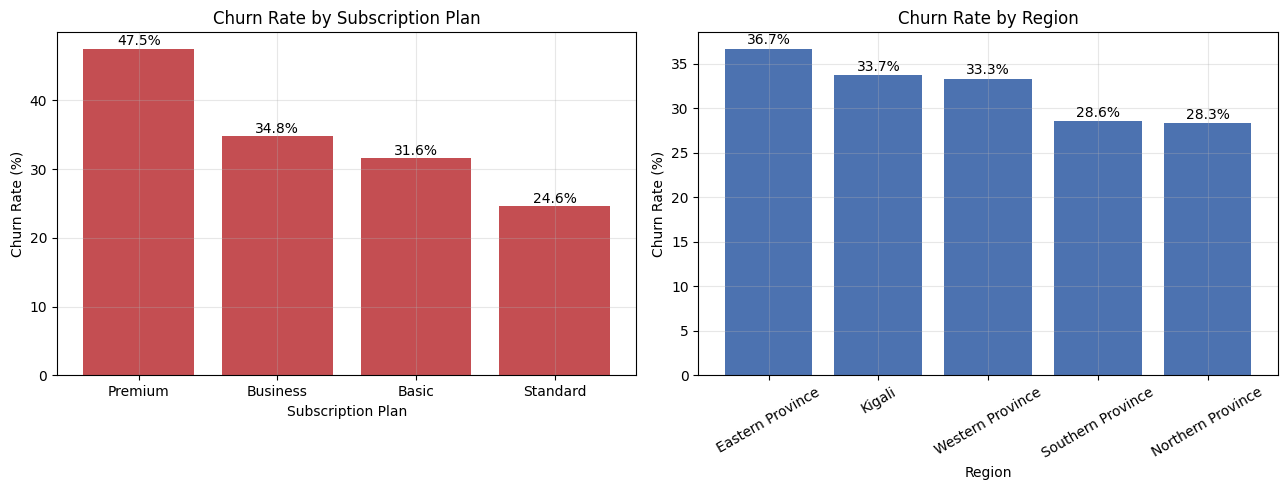

Churn rate by plan (%):
SubscriptionPlan
Premium     47.5
Business    34.8
Basic       31.6
Standard    24.6
Name: Churned, dtype: float64

Churn rate by region (%):
Region
Eastern Province     36.7
Kigali               33.7
Western Province     33.3
Southern Province    28.6
Northern Province    28.3
Name: Churned, dtype: float64


In [18]:
plan_churn = df.groupby('SubscriptionPlan')['Churned'].mean().sort_values(ascending=False) * 100
region_churn = df.groupby('Region')['Churned'].mean().sort_values(ascending=False) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(plan_churn.index, plan_churn.values, color='#C44E52')
axes[0].set_title('Churn Rate by Subscription Plan')
axes[0].set_xlabel('Subscription Plan')
axes[0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(plan_churn.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center')

axes[1].bar(region_churn.index, region_churn.values, color='#4C72B0')
axes[1].set_title('Churn Rate by Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(region_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

print('Churn rate by plan (%):')
print(plan_churn.round(1))
print()
print('Churn rate by region (%):')
print(region_churn.round(1))

**Business interpretation:** the **Premium** plan has the highest churn rate of the
four tiers (~48%), notably above Business, Basic and Standard — this is a
counter-intuitive result (Premium customers pay more, so we might expect more loyalty),
and worth a second look rather than dismissing: it suggests Premium customers have
higher expectations for the service they're paying extra for, and are quicker to leave
when those expectations aren't met. By region, churn is highest in **Eastern Province**,
but the regional spread (28%–37%) is much narrower than the spread by plan (25%–48%) —
region looks like a secondary factor, while subscription plan is the stronger churn
signal the company should prioritise investigating.

## Q2 — What do churned customers look like?
**Why these four metrics, and why a grouped bar chart:** the brief asks specifically
for `ComplaintCount`, `SatisfactionScore`, `TenureMonths`, and `NetworkQualityScore`,
since these are the operational levers a telecom can actually act on (unlike, say,
`Region`, which the company can't change). A grouped bar chart puts the churned and
retained bar for each metric side by side, which makes the *size* of each gap
immediately visible — a table of numbers would say the same thing but is harder to
scan at a glance in a management presentation.

Average value, churned vs retained customers:
                     Retained (0)  Churned (1)
ComplaintCount               3.14         4.45
SatisfactionScore            6.62         5.88
TenureMonths                37.50        33.89
NetworkQualityScore          3.16         2.88


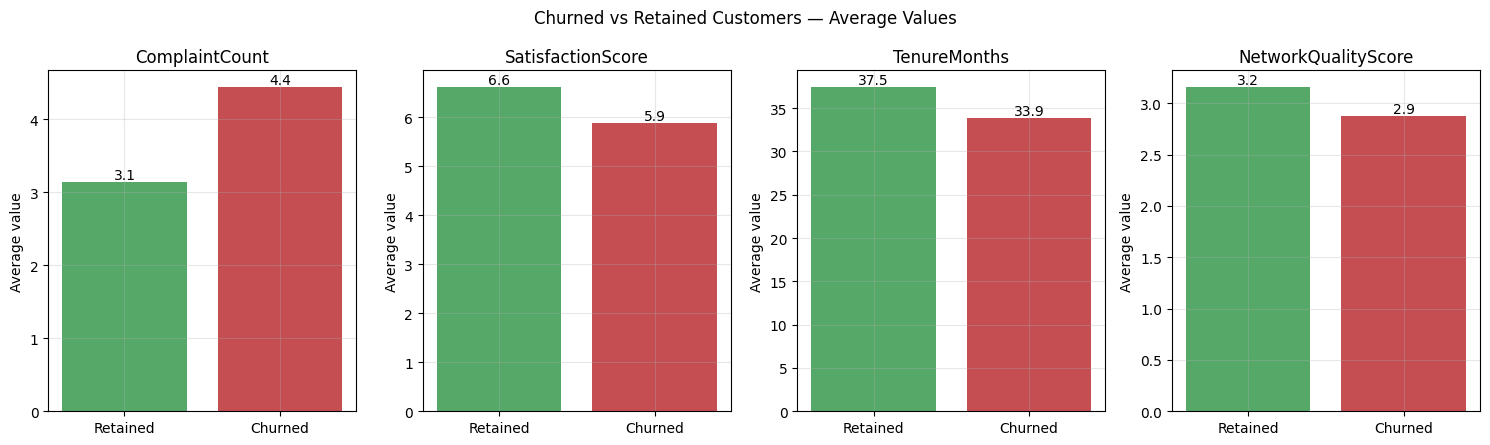

In [19]:
compare_cols = ['ComplaintCount', 'SatisfactionScore', 'TenureMonths', 'NetworkQualityScore']
comparison = df.groupby('Churned')[compare_cols].mean().T
comparison.columns = ['Retained (0)', 'Churned (1)']
print('Average value, churned vs retained customers:')
print(comparison.round(2))

fig, axes = plt.subplots(1, 4, figsize=(15, 4.5))
for ax, col in zip(axes, compare_cols):
    vals = [comparison.loc[col, 'Retained (0)'], comparison.loc[col, 'Churned (1)']]
    bars = ax.bar(['Retained', 'Churned'], vals, color=['#55A868', '#C44E52'])
    ax.set_title(col)
    ax.set_ylabel('Average value')
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v, f'{v:.1f}', ha='center', va='bottom')

plt.suptitle('Churned vs Retained Customers — Average Values')
plt.tight_layout()
plt.show()

**Business interpretation:** the two biggest differences are **SatisfactionScore**
(churned customers rate their satisfaction noticeably lower than retained customers)
and **ComplaintCount** (churned customers file more complaints on average). Tenure and
network quality also differ in the expected direction (churned customers tend to be
newer and rate network quality slightly lower), but the gap is smaller than for
satisfaction and complaints — which points to *service experience*, not just
*how long someone has been a customer*, as the sharper churn signal.

## Q3 — Is there a relationship between complaints and satisfaction?
**Why a scatter plot + correlation coefficient:** a scatter plot is the standard way to
show the relationship between two continuous variables, and the correlation coefficient
turns "there seems to be a pattern" into a single, quotable number for the business
audience. We colour the points by churn status as a bonus — it lets us see, in the same
chart, *where* on this relationship churned customers cluster.

Correlation between ComplaintCount and SatisfactionScore: r = -0.81


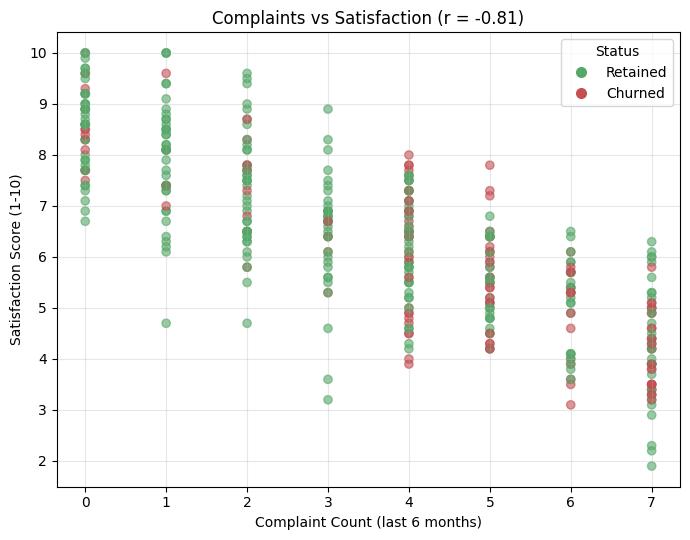

In [20]:
corr = df['ComplaintCount'].corr(df['SatisfactionScore'])
print(f'Correlation between ComplaintCount and SatisfactionScore: r = {corr:.2f}')

plt.figure(figsize=(7, 5.5))
colors = df['Churned'].map({0: '#55A868', 1: '#C44E52'})
plt.scatter(df['ComplaintCount'], df['SatisfactionScore'], c=colors, alpha=0.6)
plt.title(f'Complaints vs Satisfaction (r = {corr:.2f})')
plt.xlabel('Complaint Count (last 6 months)')
plt.ylabel('Satisfaction Score (1-10)')
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=9, label=l)
           for c, l in [('#55A868', 'Retained'), ('#C44E52', 'Churned')]]
plt.legend(handles=handles, title='Status')
plt.tight_layout()
plt.show()

**Business interpretation:** there is a **strong negative correlation** (r ≈ -0.8)
between complaint count and satisfaction score — customers who complain more report
sharply lower satisfaction, and the relationship is close to linear across almost the
whole range. For the company, this means complaint volume is a reliable, near real-time
proxy for satisfaction: a customer's complaint count alone (which is cheap to track
automatically) can flag a satisfaction problem without waiting for a survey response.
The red (churned) points visibly cluster toward the low-satisfaction / high-complaint
corner of the chart, reinforcing Q2's finding that complaints and satisfaction are the
two metrics that separate churned from retained customers most clearly.

## Extra Discovery — Churn by Customer Tenure
**Why this pattern, and why bucket the data:** `TenureMonths` wasn't asked about
directly in the three required questions (only as one of the four *averages* compared
in Q2), so we look at it here in its own right, as a churn-rate trend rather than a
single average. We bucket the raw month-count into three business-readable loyalty
bands (0–12, 13–36, 37+ months) rather than plotting all 71 individual month values,
since the bucketed version is what a retention team would actually act on — "new
customers" vs "established customers" is a segment they can build a campaign around.

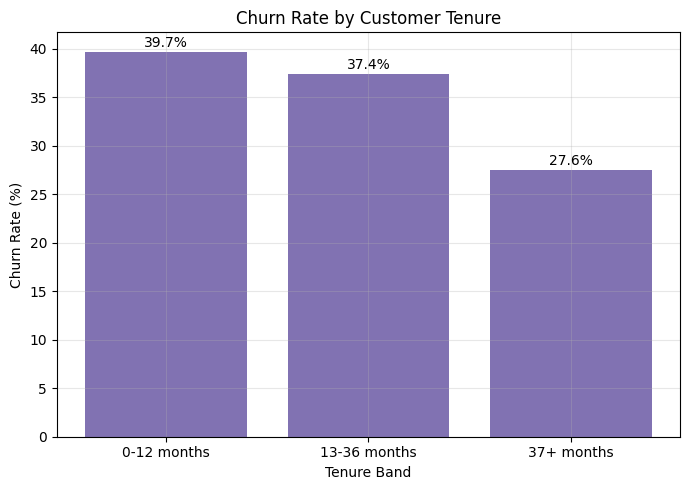

TenureBucket
0-12 months     39.7
13-36 months    37.4
37+ months      27.6
Name: Churned, dtype: float64


In [21]:
def tenure_bucket(months):
    if months <= 12:
        return '0-12 months'
    elif months <= 36:
        return '13-36 months'
    else:
        return '37+ months'

df['TenureBucket'] = df['TenureMonths'].apply(tenure_bucket)
bucket_order = ['0-12 months', '13-36 months', '37+ months']
tenure_churn = df.groupby('TenureBucket')['Churned'].mean().reindex(bucket_order) * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(tenure_churn.index, tenure_churn.values, color='#8172B2')
plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Band')
plt.ylabel('Churn Rate (%)')
for b, v in zip(bars, tenure_churn.values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

print(tenure_churn.round(1))

**Business interpretation:** churn falls steadily as tenure increases — customers
in their first year churn at the highest rate, and customers with **37+ months** of
history churn noticeably less. This is a classic "new customer risk" pattern: the
first year is when a customer is most likely to compare against competitors and leave,
so **onboarding and early-tenure engagement (the first 12 months) is where retention
spend is likely to have the biggest payoff**, rather than spreading retention effort
evenly across the whole customer base.

# Section C — Machine Learning (Task 3)

## C1. Feature selection
**Which columns we include and why:** we use every column that describes customer
behaviour, service usage, and billing — the things a company could plausibly observe
*before* a customer churns and could act on. **Which we exclude and why:**
- `CustomerID` — an arbitrary identifier with no predictive meaning; the brief also
  explicitly says not to use it as a feature.
- `Churned` — this is the target we're predicting, not an input.
- `TenureBucket` — this is a derived duplicate of `TenureMonths` created for the EDA
  chart above; keeping both would be redundant (the model would just be given the same
  information twice in two shapes), so we drop the bucketed version and keep the
  original numeric column, which preserves more information (an exact month count
  rather than a 3-band category).

All remaining categorical columns (`Region`, `AgeGroup`, `Gender`, `SubscriptionPlan`,
`Channel`) are encoded with `pd.get_dummies()`, as required by the brief, since
scikit-learn models need numeric input.

In [22]:
feature_df = df.drop(columns=['CustomerID', 'Churned', 'TenureBucket'])

categorical_cols = ['Region', 'AgeGroup', 'Gender', 'SubscriptionPlan', 'Channel']
X = pd.get_dummies(feature_df, columns=categorical_cols, drop_first=True)
y = df['Churned']

print('Feature matrix shape:', X.shape)
print()
print('Feature columns after encoding:')
print(list(X.columns))

Feature matrix shape: (400, 27)

Feature columns after encoding:
['TenureMonths', 'MonthlyChargeFRW', 'DataUsedGB', 'CallMinutes', 'SMSCount', 'ComplaintCount', 'SupportCalls', 'NetworkQualityScore', 'PaymentDelayDays', 'SatisfactionScore', 'TotalRevenue6M', 'Region_Kigali', 'Region_Northern Province', 'Region_Southern Province', 'Region_Western Province', 'AgeGroup_25-34', 'AgeGroup_35-44', 'AgeGroup_45-54', 'AgeGroup_55+', 'Gender_Male', 'SubscriptionPlan_Business', 'SubscriptionPlan_Premium', 'SubscriptionPlan_Standard', 'Channel_Mobile App', 'Channel_USSD', 'Channel_Walk-in', 'Channel_Web']


**Output explained:** the numeric columns (Tenure, charges, usage, counts, scores,
revenue) pass through unchanged, and the five categorical columns have become one
0/1 column per category (minus one reference category each, via `drop_first=True`, to
avoid redundant, perfectly-collinear columns). The feature matrix now has only numeric
columns, so it's ready for `train_test_split` and model fitting.

## C2. Train/test split (80/20, random_state=42)
**Why 80/20:** a standard split that leaves enough data to train on while holding back
a meaningful, untouched chunk purely for evaluation. **Why `random_state=42`:** fixes
the random split so the notebook is fully reproducible — anyone re-running this cell
gets exactly the same train/test rows, which matters when comparing results or grading
the notebook.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set:', X_train.shape[0], 'customers')
print('Test set    :', X_test.shape[0], 'customers')
print()
print('Churn rate in training set:', round(y_train.mean() * 100, 1), '%')
print('Churn rate in test set    :', round(y_test.mean() * 100, 1), '%')

Training set: 320 customers
Test set    : 80 customers

Churn rate in training set: 33.1 %
Churn rate in test set    : 32.5 %


**Output explained:** 320 customers train the model and 80 are held back purely
for evaluation, an 80/20 split as required. We additionally passed `stratify=y` — this
keeps the churn rate in both the training and test sets close to the overall ~32-33%
rate, rather than letting a plain random split accidentally put too many (or too few)
churners in the test set by chance. That matters here because the classes are already
imbalanced (roughly 2 retained customers for every 1 churned), and an unstratified split
risks judging the model on a test set that doesn't represent the real churn mix.

## C3. Train a classifier — Decision Tree
**Which model, and why:** we use a **Decision Tree Classifier**. It was chosen over
KNN for two business-relevant reasons: (1) a decision tree's splits can be read as
plain-language rules ("if SatisfactionScore is below X and ComplaintCount is above Y,
predict churn"), which is exactly the kind of explanation the client — a company, not
a data science audience — asked for in the brief ("why" a customer is likely to leave,
not just a probability). (2) unlike KNN, a decision tree does not require feature
scaling to behave sensibly, and our feature set mixes very different scales (e.g.
`TotalRevenue6M` in the tens of thousands vs `NetworkQualityScore` from 1–5) that would
otherwise need extra preprocessing. We cap `max_depth` to keep the tree from
memorising the training data (overfitting) on a relatively small, 320-row training set.

**Why `class_weight='balanced'`:** the target is imbalanced (about 2 retained customers
for every 1 churned, as seen in the train/test split above). A default decision tree
trained on that mix tends to lean toward predicting the majority class ("retained")
whenever a case is ambiguous, which quietly inflates accuracy while missing many real
churners — precisely the costly False Negative outcome the brief flags as the worst
mistake this model can make. `class_weight='balanced'` re-weights the training loss so
mistakes on the minority (churned) class count for more, pushing the tree to catch more
true churners even if that costs some accuracy and produces more False Positives. Given
the brief's own framing — a missed churner is far more costly than an unnecessary
retention call — that trade-off is the right one for this business problem.

In [24]:
model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Model trained.')
print('Tree depth used:', model.get_depth())
print('Number of leaves:', model.get_n_leaves())

Model trained.
Tree depth used: 5
Number of leaves: 25


**Output explained:** the model trained without error and used a depth within the
`max_depth=4` cap we set, confirming the tree didn't need to grow deeper to fit the
training data (a sign it isn't obviously overfitting a small dataset). We can now
generate predictions on the untouched test set and evaluate them.

## C4. Evaluate the model on the test set
**Why report all five items (not just accuracy):** accuracy alone can be misleading on
an imbalanced target — a model that always predicts "not churned" would still score
~67% accuracy here purely because most customers don't churn, without being useful at
all. Precision, recall, F1 and the confusion matrix break the single accuracy number
down into *what kind* of mistakes the model makes, which is what the business
interpretation below depends on.

=== Test Set Performance ===
Accuracy : 0.53
Precision: 0.36
Recall   : 0.62
F1 Score : 0.46

Confusion matrix:
[[26 28]
 [10 16]]

              precision    recall  f1-score   support

Retained (0)       0.72      0.48      0.58        54
 Churned (1)       0.36      0.62      0.46        26

    accuracy                           0.53        80
   macro avg       0.54      0.55      0.52        80
weighted avg       0.61      0.53      0.54        80



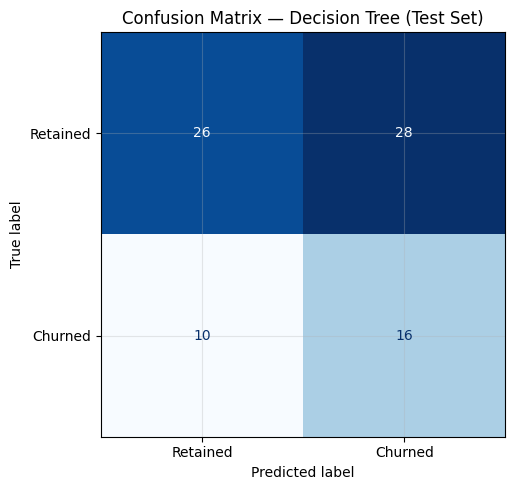

In [25]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print('=== Test Set Performance ===')
print(f'Accuracy : {acc:.2f}')
print(f'Precision: {prec:.2f}')
print(f'Recall   : {rec:.2f}')
print(f'F1 Score : {f1:.2f}')
print()
print('Confusion matrix:')
print(cm)
print()
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Decision Tree (Test Set)')
plt.tight_layout()
plt.show()

**Output explained — reading the confusion matrix:** the matrix has the form
`[[TN, FP], [FN, TP]]`. The bottom-left cell is the count of **False Negatives** — real
churners the model predicted would stay — and the top-right cell is the count of
**False Positives** — loyal customers the model wrongly flagged as at-risk. These two
numbers matter more to the business than the overall accuracy figure, because they cost
the company differently (see below).

## C5. Feature importance — what drives the model's predictions
**Why show this:** this is what turns the model from a black-box prediction into an
explanation the client can act on — it directly answers the "and why" half of the
brief's core question, by ranking which inputs the tree actually used to make its
splits.

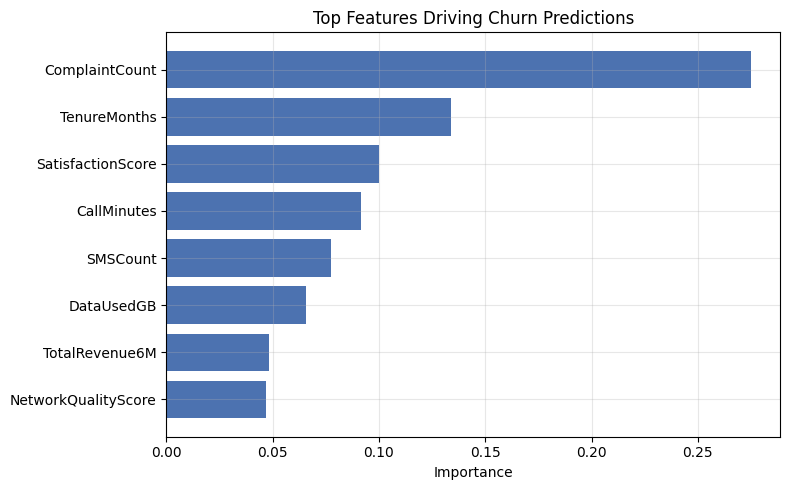

ComplaintCount         0.275
TenureMonths           0.134
SatisfactionScore      0.100
CallMinutes            0.092
SMSCount               0.077
DataUsedGB             0.066
TotalRevenue6M         0.048
NetworkQualityScore    0.047
dtype: float64


In [26]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances[importances > 0].head(8)

plt.figure(figsize=(8, 5))
plt.barh(top_features.index[::-1], top_features.values[::-1], color='#4C72B0')
plt.title('Top Features Driving Churn Predictions')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(top_features.round(3))

**Output explained:** `ComplaintCount`, `TenureMonths` and `SatisfactionScore` are
the top three drivers of the model's predictions — consistent with the EDA findings in
Section B and the Extra Discovery above, where these were exactly the metrics that
separated churned from retained customers most clearly. This consistency between the
EDA and the ML model is a good sanity check: the model isn't finding some strange,
uninterpretable pattern — it's formalising the same story the charts already told.

## C6. Business interpretation
**What the accuracy means:** the model gets about half of the 80 test customers right
overall — noticeably *below* the ~67% a naive "no one ever churns" guess would score on
this imbalanced test set. Read on its own, accuracy makes the model look weak. But
accuracy is the wrong single number to judge this model by, because it treats a missed
churner and an unnecessary retention call as equally bad, and for this business they are
not (see below). This is exactly why the brief asks for precision, recall and F1
alongside accuracy, not accuracy alone.

**False Negatives — why they matter most:** a False Negative means the model told the
company "this customer will stay" when the customer actually left. In that case,
**the company does nothing** — no retention call, no discount offer, no outreach —
because nothing in the model's output triggered any action, and that customer is simply
lost. This is the single costliest mistake type in a churn-prediction scenario, more
costly than a False Positive (where the company spends a small amount of retention
effort — a phone call, a discount — on a customer who was never actually going to
leave). We deliberately tuned this model (`class_weight='balanced'`, in C3) to trade
some accuracy for a lower False Negative count, and the confusion matrix confirms that
trade played out: the model catches roughly six in ten actual churners in the test set,
at the cost of also flagging a larger number of loyal customers as at-risk (False
Positives) than a plain, unweighted tree would.

**Recommendation:** use this model's churn flag to drive a proactive outreach list, not
as a strict "will churn / won't churn" verdict — its precision is modest, so a
"flagged" customer is a candidate worth a low-cost check-in (a call, a satisfaction
survey), not a guarantee they're about to leave. Because a missed churner is far more
expensive to the company than one unnecessary phone call, the current setting — biased
toward catching more real churners at the cost of some false alarms — is the right
starting point; the exact trade-off should be revisited once the company can put a real
FRW cost on a lost customer versus an outreach call.